<a href="https://colab.research.google.com/github/FattahulAlim/MFattahul-PCVK_ganjil_2026/blob/main/Week6_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identitas Diri
Nama: Muhammad Fattahul Alim

NIM: 244107020018

Kelas: TI - 3G

Absen : 15

In [ ]:
NAMA = 'Muhammad Fattahul Alim'
NIM = '244107020018' # ganti dengan NIM sendiri
print(NAMA, NIM)

Muhammad Fattahul Alim 244107020018


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [ ]:
# Fungsi convolution 2D
def convolution2d(image, kernel, stride=1, padding=0):
    height, width = image.shape[0], image.shape[1]
    kH, kW = kernel.shape

    # 1. ukuran output (untuk loop)
    out_h = (height + 2*padding - kH) // stride + 1
    out_w = (width  + 2*padding - kW) // stride + 1
    output = np.zeros((out_h, out_w), dtype=np.float32)

    # 2. mulai loop dari (0,0)
    for i in range(out_h):
        for j in range(out_w):
            total = 0
            for m in range(kH):
                for n in range(kW):
                    # koordinat di gambar ASLI
                    y = i*stride + m - padding
                    x = j*stride + n - padding

                    y = min(max(y, 0), height - 1)
                    x = min(max(x, 0), width - 1)
                    pixel = image[y, x]

                    total += pixel * kernel[m, n]

            # 4. simpan ke koordinat sekarang
            output[i, j] = total

    return output

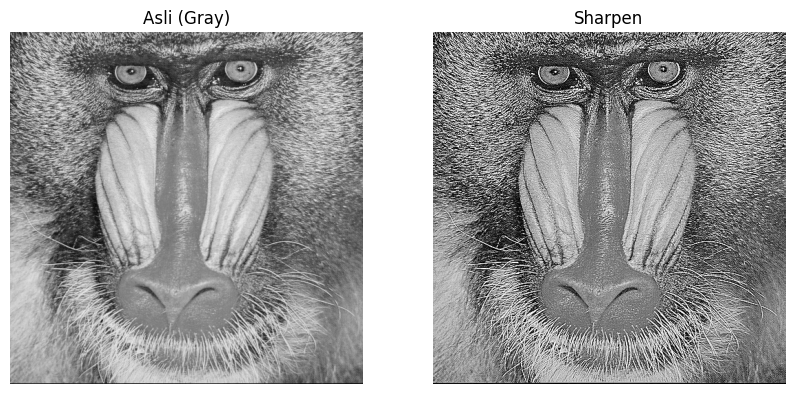

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_sharpen = np.array([[0, -1, 0], [-1,5,-1], [0,-1,0]])

# simpan hasilnya ke variabel
hasil = convolution2d(img_gray, kernel_sharpen, 1, 2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Asli (Gray)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Sharpen')
plt.axis('off')

plt.show()

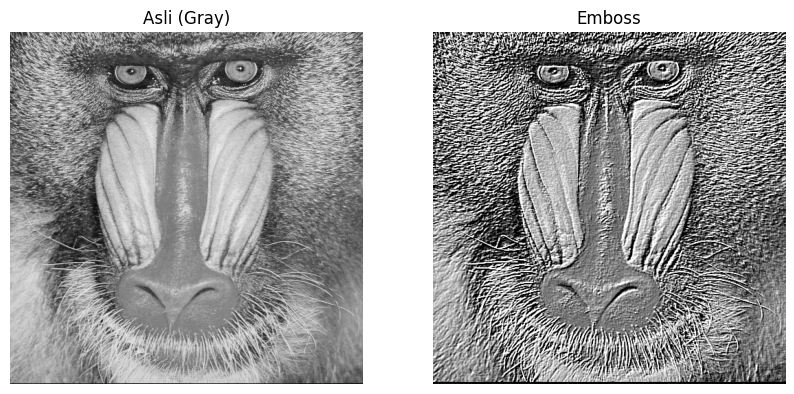

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_emboss = np.array([[-2, -1, 0], [-1,1,1], [0,1,2]])

# simpan hasilnya ke variabel
hasil = convolution2d(img_gray, kernel_emboss, 1, 2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Asli (Gray)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Emboss')
plt.axis('off')

plt.show()

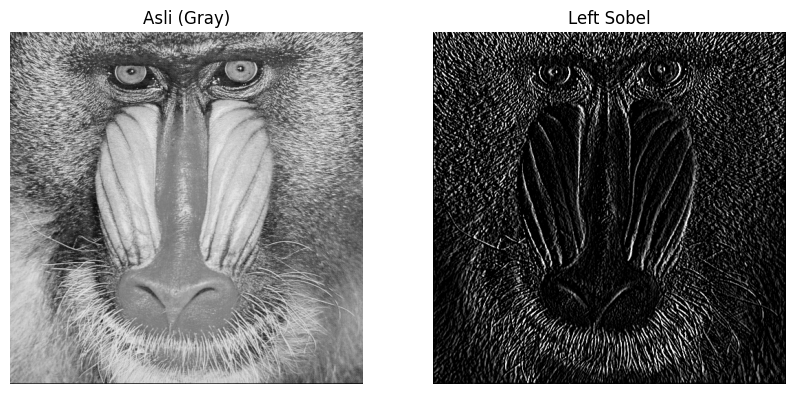

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_left_sobel = np.array([[1, 0, -1], [2,0,-2], [1,0,-1]])

# simpan hasilnya ke variabel
hasil = convolution2d(img_gray, kernel_left_sobel, 1, 2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Asli (Gray)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Left Sobel')
plt.axis('off')

plt.show()

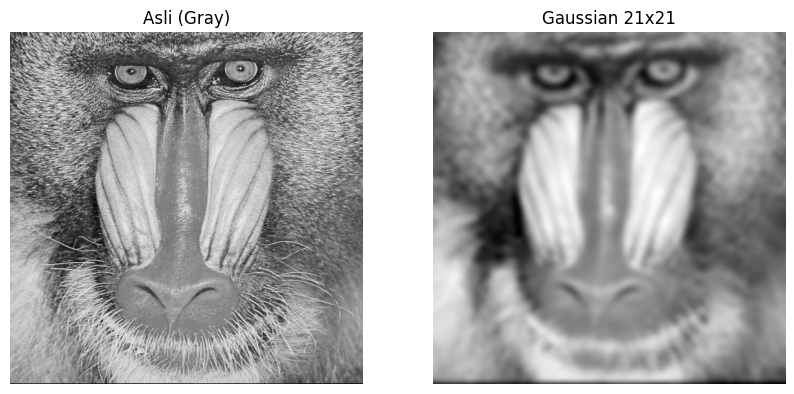

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_size = 21
sigma = math.sqrt(kernel_size)

gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)   # bentuk (21, 1)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose() # jadi (21, 21)

hasil = convolution2d(img_gray, gauss_kernel, 1, kernel_size // 2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Asli (Gray)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title('Gaussian 21x21')
plt.axis('off')

plt.show()

# Filter Library dan Filter modern

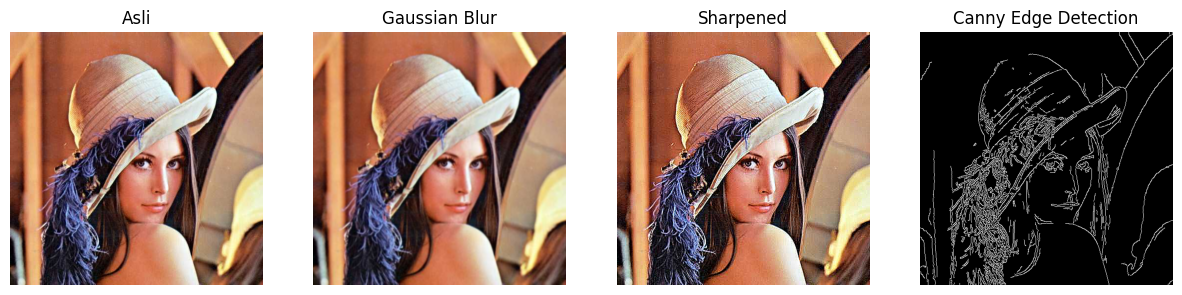

In [ ]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/lena.jpg')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

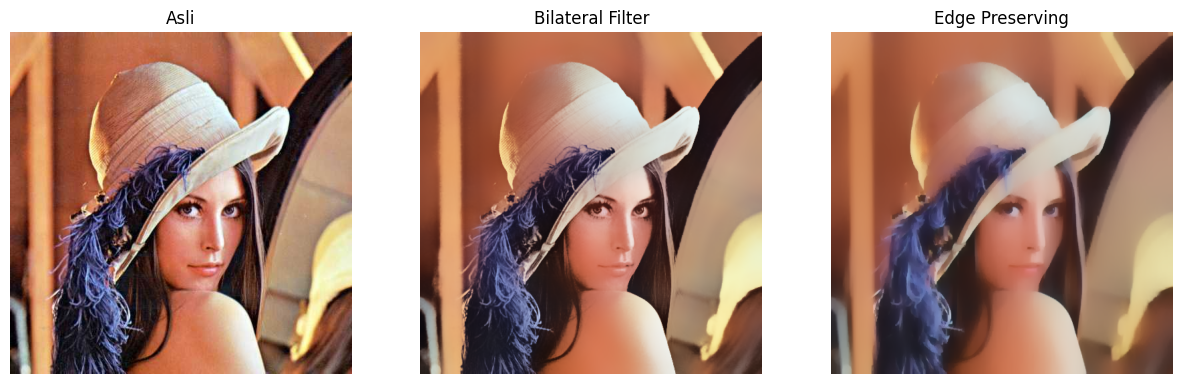

In [ ]:
# Bilateral Filter
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving
edge_preserved = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserved],
                  ["Asli", "Bilateral Filter", "Edge Preserving"])


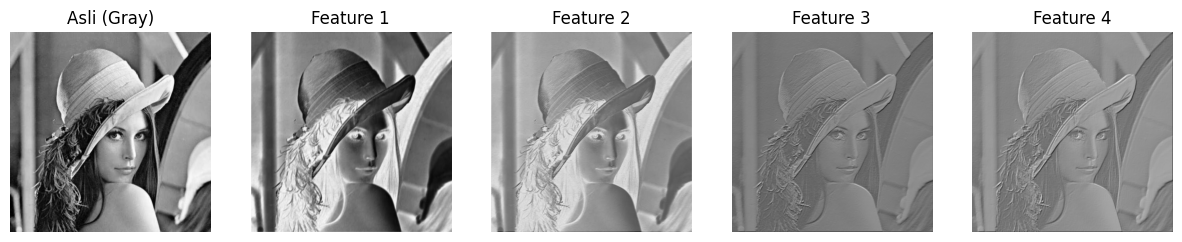

In [ ]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

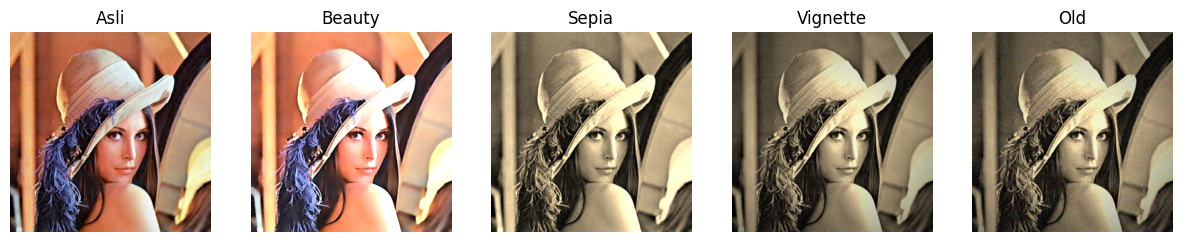

In [ ]:
# 1. Beauty Filter
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)
show_side_by_side([img, beauty, sepia, vignette, old_img],
                  ["Asli", "Beauty", "Sepia", "Vignette", "Old"])

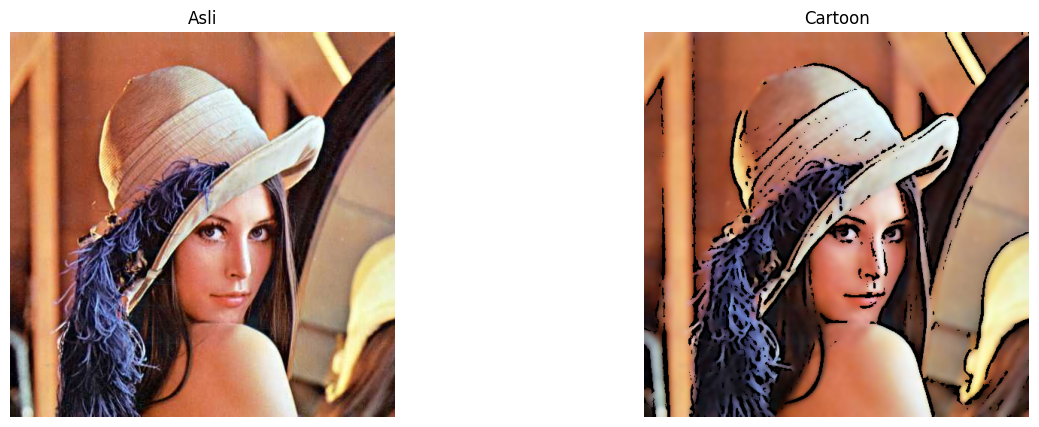

In [ ]:
# Filter anime / cartoon
# Step 1: Edge detection (menggunakan median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blurred = cv.medianBlur(gray, 5)
edges = cv.adaptiveThreshold(blurred, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# Step 2 : Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

#Step 3 : Gabungkan
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon],
                  ["Asli", "Cartoon"])

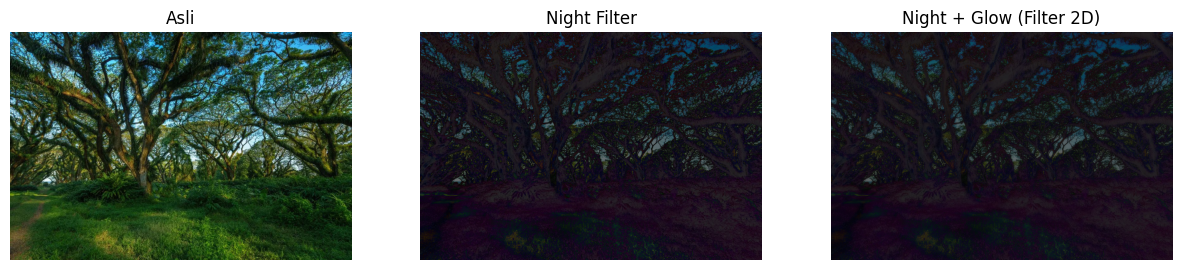

In [ ]:
# Night Filter
img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/djawatan.jpg')

# Step 1 : Gelapkan(Contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2 : Tambah bias biru
blue_tint= np.full_like(night, (50,0,100)) # BGR

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 255
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (Filter 2D)"])

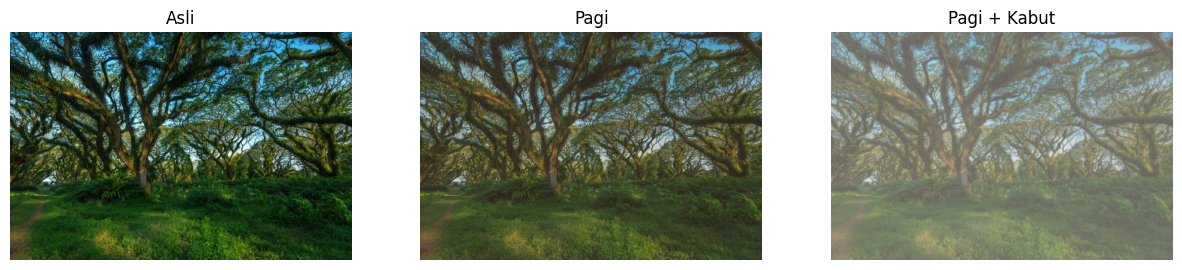

In [ ]:
#Filter Suasana pagi dan Kabut
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9    # contrast
beta = 20      # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

# Tugas Praktikum

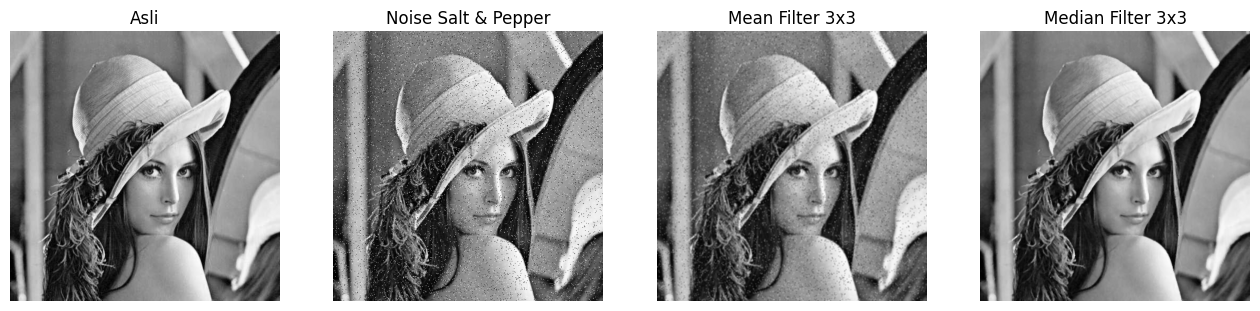

In [ ]:
# Tugas Praktikum 1
img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 1. Tambah noise salt & pepper
np.random.seed(42)
amount = 0.05
noisy = img_gray.copy()
r = np.random.rand(*img_gray.shape)
noisy[r < amount/2] = 0          # pepper (hitam)
noisy[r > 1 - amount/2] = 255    # salt (putih)

#2 Menambahkan padding replicate dengan ukuran filter 3x3
size = 3
pad = size // 2
padded = np.pad(noisy, pad, mode='edge')
H, W = noisy.shape

#3 Menghitung mean dan median
mean_result = np.zeros((H, W), dtype=np.float32)
median_result = np.zeros((H, W), dtype=np.uint8)

for i in range(H):
    for j in range(W):
        region = padded[i:i+size, j:j+size]    # jendela 3x3
        mean_result[i, j] = np.mean(region)    # mean filter
        median_result[i, j] = np.median(region)  # median filter

mean_result = np.clip(mean_result, 0, 255).astype(np.uint8)
show_side_by_side(
    [img_gray, noisy, mean_result, median_result],
    ["Asli", "Noise Salt & Pepper", "Mean Filter 3x3", "Median Filter 3x3"],
    figsize=(16, 4)
)

In [ ]:
asli = img_gray.astype(np.float32)

print("MSE noise  :", np.mean((noisy.astype(np.float32) - asli)**2))
print("MSE mean   :", np.mean((mean_result.astype(np.float32) - asli)**2))
print("MSE median :", np.mean((median_result.astype(np.float32) - asli)**2))

MSE noise  : 1017.95605
MSE mean   : 168.71156
MSE median : 32.872486


Median filter memang lebih efektif dalam menghilangkan noise salt dan pepper daripada mean filter. Hal ini karena noise tersebut berupa nilai ekstrem yaitu 0 dna 255 yang pada mean filter akan ikut terhitung dalam rata rata sehingga dapat tersamarkan dengan menyebar nilai piksel ekstrem tersebut ke piksel sekitar. Sedangkan, pada median filter nilai ekstre, berada di ujung urutan sehingga tidak terpilih sebaagi nilai tengah. Selain ityu meidan filter menjaga ketajaman tepi sementara mean filter membuat gambar menjadi buram

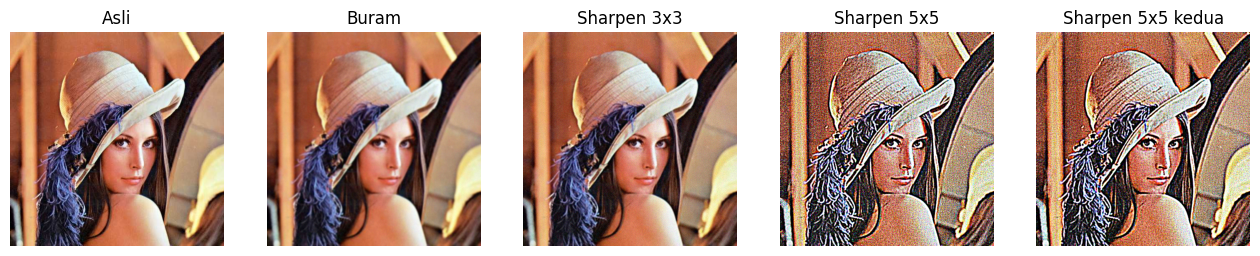

In [ ]:
# Tugas Praktkum 2
img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/lena.jpg')
# Kernel sharpening 3x3
kernel3 = np.array([[ 0, -1,  0],
                     [-1,  5, -1],
                     [ 0, -1,  0]], dtype=np.float32)

# Kernel sharpening 5x5
kernel5 = np.array([[-1, -1, -1, -1, -1],
                     [-1, -1, -1, -1, -1],
                     [-1, -1, 25, -1, -1],
                     [-1, -1, -1, -1, -1],
                     [-1, -1, -1, -1, -1]], dtype=np.float32)

kernel5_2 = np.array([[-1, -1, -1, -1, -1],
                     [-1, 0, 0, 0, -1],
                     [-1, 0, 17, 0, -1],
                     [-1, 0, 0, 0, -1],
                     [-1, -1, -1, -1, -1]], dtype=np.float32)

# Membuat gambar sedikit buram dan menambahkan noise halus
np.random.seed(42)
blur = cv.GaussianBlur(img, (5, 5), 1.5)
noise = np.random.normal(0, 3, blur.shape)
blurry = np.clip(blur.astype(np.float32) + noise, 0, 255).astype(np.uint8)

# Sharpening dengan filter2D
hasil3 = cv.filter2D(blurry, -1, kernel3)
hasil5 = cv.filter2D(blurry, -1, kernel5)
hasil5_2 = cv.filter2D(blurry, -1, kernel5_2)

show_side_by_side(
    [img, blurry, hasil3, hasil5, hasil5_2],
    ["Asli", "Buram", "Sharpen 3x3", "Sharpen 5x5", "Sharpen 5x5 kedua"],
    figsize=(16, 4)
)

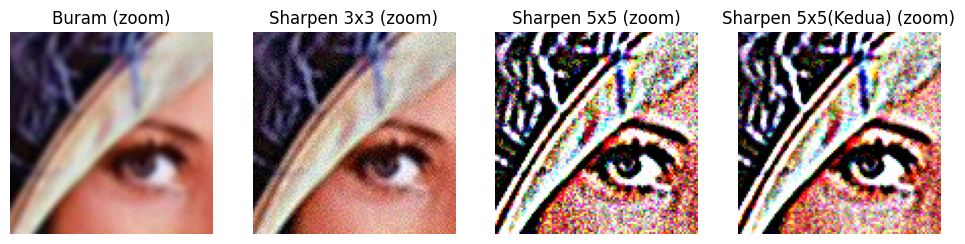

In [ ]:
y1, y2, x1, x2 = 200, 300, 200, 300   # geser ke area yang ada tepinya (topi, mata)
show_side_by_side(
    [blurry[y1:y2, x1:x2], hasil3[y1:y2, x1:x2], hasil5[y1:y2, x1:x2], hasil5_2[y1:y2, x1:x2]],
    ["Buram (zoom)", "Sharpen 3x3 (zoom)", "Sharpen 5x5 (zoom)", "Sharpen 5x5(Kedua) (zoom)"],
    figsize=(12, 4)
)

In [ ]:
# MSE tiap hasil dibandingkan dengan Lena asli
asli = img.astype(np.float32)

nama_list  = ["Buram", "Sharpen 3x3", "Sharpen 5x5", "Sharpen 5x5 kedua"]
gambar_list = [blurry, hasil3, hasil5, hasil5_2]

hasil_mse = []
for nama, g in zip(nama_list, gambar_list):
    nilai = np.mean((g.astype(np.float32) - asli) ** 2)
    hasil_mse.append(nilai)
    print(f"{nama:20s} | MSE: {nilai:10.2f}")

datar = (slice(20, 60), slice(20, 60))   # ganti ke area yang benar-benar mulus

print()
for nama, g in zip(nama_list, gambar_list):
    g_gray = cv.cvtColor(g, cv.COLOR_BGR2GRAY)
    tajam = cv.Laplacian(g_gray, cv.CV_64F).var()
    std_datar = g_gray[datar].std()
    print(f"{nama:20s} | Ketajaman: {tajam:10.2f} | Std area datar: {std_datar:6.2f}")

Buram                | MSE:      89.55
Sharpen 3x3          | MSE:     290.75
Sharpen 5x5          | MSE:    4857.23
Sharpen 5x5 kedua    | MSE:    3323.08

Buram                | Ketajaman:     113.16 | Std area datar:  12.99
Sharpen 3x3          | Ketajaman:    3622.15 | Std area datar:  16.99
Sharpen 5x5          | Ketajaman:   32689.70 | Std area datar:  48.24
Sharpen 5x5 kedua    | Ketajaman:   17937.97 | Std area datar:  38.49


Berdasarkan hasil mse di atas kernel 3x3 (MSE = 290.75) adalah yang terbaik di antara ketiga kernel jika dinilai dari kemiripan citra dengan yang aslinya diikuti oleh kernel 5x5 kedua (MSE = 3323.08) dan kernel 5x5 pertama (MSE=4957.23). Namun, jika dilihat dari ketajaman tepian nya maka kernel 5x5 pertama memiliki ketajaman yang paling tinggi (32689.70) namun nilai ini dipengaruhi oleh noise yang ikut terangkat, bukan hanya oleh tepi. Hal ini terlihat dari std area datar yang meningkat tajam pada kernel 5x5 (48,24 dan 38,49) dibandingkan kernel 3x3 (16,99) dan citra buram (12,99). Secara visual, kernel 5x5 juga menghasilkan bintik warna dan halo pada tepi.

Kesimpulan: Kernel 3x3 mendapatkan hasil terbaik pada praktikum kali ini. Meskipun ketajamannya tidak setinggi kernel 5x5 namun noise yang dihasilkan juga tidak sebanyak kernel 5x5 sehingga hasil citra menjadi lebih jelas terlihat. Semua itu dipengaruhi juga oleh nilai kernel yang digunakan, mungkin nilai kernel yang digunakan pada kernel 5x5 masih kurang optimal sehingga citra yang dihasilkan juga masih kurang optimal

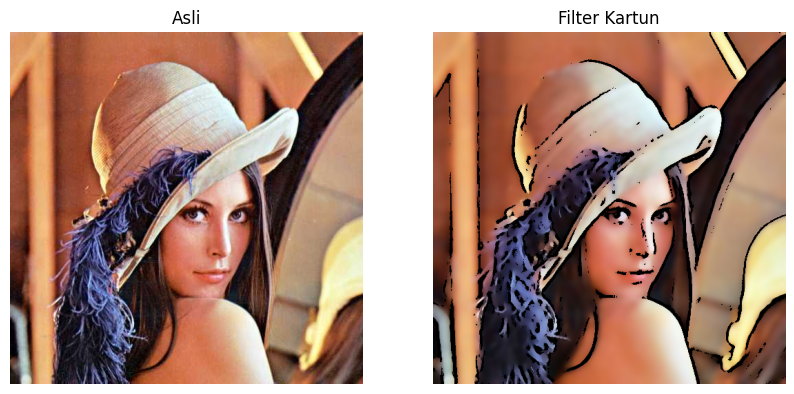

In [ ]:
# Tugas 3
def kartun(image):
    # 1. Deteksi garis tepi (adaptive thresholding)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)
    # edges: garis = 0 (hitam), selain garis = 255 (putih)

    # 2. Penghalusan warna (bilateral filter), diulang biar makin rata
    color = image.copy()
    for _ in range(3):
        color = cv.bilateralFilter(color, d=9, sigmaColor=75, sigmaSpace=75)

    # 3. Gabungkan lewat perkalian piksel
    mask = (edges / 255.0)[:, :, np.newaxis]          # 0 atau 1, dibuat 3 channel
    hasil = (color.astype(np.float32) * mask).astype(np.uint8)

    return hasil

img = cv.imread('/content/drive/MyDrive/PCVK-MFattahul/week-6/lena.jpg')

hasil_kartun = kartun(img)
show_side_by_side([img, hasil_kartun], ["Asli", "Filter Kartun"], figsize=(10, 5))

Filter kartun dibuat dengan menggabungkan dua proses. Pertama, garis tepi dideteksi dengan mengubah citra ke grayscale, memburamkannya dengan median blur untuk menghilangkan detail halus, lalu menerapkan adaptive thresholding sehingga menghasilkan mask biner berupa garis hitam di latar putih. Kedua, warna citra dihaluskan menggunakan bilateral filter yang diulang tiga kali, sehingga area warna menjadi rata tanpa mengaburkan batas antar objek. Terakhir, kedua hasil digabungkan dengan perkalian piksel: citra warna dikalikan mask garis (0 pada garis dan 1 pada selain garis), sehingga piksel garis menjadi hitam dan sisanya mempertahankan warna yang telah dihaluskan.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/PCVK-MFattahul/week-6/Week6_15.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/PCVK-MFattahul/week-6/Week6_15.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 9396050 bytes to /content/drive/MyDrive/PCVK-MFattahul/week-6/Week6_15.html
